# 01 — Dataset Validation

> **Goal:** Scan every image and YOLO label across all splits, detect quality issues, and emit a structured log for downstream notebooks.

**Checks performed:**
- Image readability (corrupt / empty files)
- Missing label files
- YOLO annotation format (exactly 5 numeric fields per line)
- Normalised coordinate range `[0, 1]`
- Valid class IDs against `data.yaml`
- Degenerate bounding boxes (zero / negative dimensions)

**Outputs:**
- `logs/01_validation_report_<timestamp>.json` — full issue list
- `logs/valid_files.json` — per-split lists of readable image+label pairs
- `logs/01_validation_overview.png` — overview charts

In [2]:
import subprocess, sys

REQUIRED = [
    ('cv2',      'opencv-python'),
    ('yaml',     'pyyaml'),
    ('tqdm',     'tqdm'),
    ('seaborn',  'seaborn'),
    ('pandas',   'pandas'),
    ('numpy',    'numpy'),
    ('matplotlib', 'matplotlib'),
]

for import_name, pip_name in REQUIRED:
    try:
        __import__(import_name)
    except ImportError:
        print(f'Installing {pip_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

print('All packages available.')

Installing opencv-python...
Installing pyyaml...
Installing tqdm...
Installing seaborn...
All packages available.


In [3]:
import os
import cv2
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

print('Imports complete.')

Imports complete.


## Configuration
Adjust `BASE_DIR` if the dataset lives elsewhere relative to this notebook.

In [4]:
# ── Paths ────────────────────────────────────────────────────
BASE_DIR  = Path('DATA_AFTER MERGED')   # root of the raw dataset
SPLITS    = ['train', 'valid', 'test']
LOG_DIR   = Path('logs')
LOG_DIR.mkdir(exist_ok=True)
TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')

# ── Load class names from data.yaml ─────────────────────────
yaml_path = BASE_DIR / 'data.yaml'
assert yaml_path.exists(), f'data.yaml not found at {yaml_path}'

with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

CLASS_NAMES = data_yaml['names']
NUM_CLASSES = len(CLASS_NAMES)

print(f'Dataset root  : {BASE_DIR.resolve()}')
print(f'Classes ({NUM_CLASSES})    : {CLASS_NAMES}')
print(f'Splits        : {SPLITS}')
print(f'Log directory : {LOG_DIR.resolve()}')

Dataset root  : C:\Users\shaho\OneDrive\Desktop\grad\DATA_AFTER MERGED
Classes (6)    : ['Customer-Bagpack', 'Product', 'Product-Picked', 'Shopping-Cart', 'normal', 'theft']
Splits        : ['train', 'valid', 'test']
Log directory : C:\Users\shaho\OneDrive\Desktop\grad\logs


## Validation Functions

In [5]:
IMG_EXTS = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG', '*.bmp', '*.BMP')


def collect_images(split_dir: Path) -> list:
    """Return sorted list of all image paths in a split images/ folder."""
    imgs = []
    for ext in IMG_EXTS:
        imgs.extend(split_dir.glob(ext))
    return sorted(set(imgs))


def validate_image(img_path: Path) -> dict:
    """
    Try to open an image with OpenCV.
    Returns: valid (bool), error (str|None), shape (H,W,C)|None, size_bytes (int)
    """
    res = {'valid': False, 'error': None, 'shape': None, 'size_bytes': 0}
    try:
        res['size_bytes'] = img_path.stat().st_size
        if res['size_bytes'] == 0:
            res['error'] = 'Empty file (0 bytes)'
            return res
        img = cv2.imread(str(img_path))
        if img is None:
            res['error'] = 'cv2.imread returned None — corrupt or unsupported'
            return res
        if img.size == 0:
            res['error'] = 'Decoded image array is empty'
            return res
        res['valid'] = True
        res['shape'] = img.shape   # (H, W, C)
    except Exception as e:
        res['error'] = f'{type(e).__name__}: {e}'
    return res


def validate_label(lbl_path: Path, num_classes: int) -> dict:
    """
    Validate a YOLO .txt label file.
    Returns: valid (bool), is_empty (bool), errors (list[str]), annotations (list[dict])
    """
    res = {
        'valid': True,
        'is_empty': False,
        'errors': [],
        'annotations': [],
        'invalid_line_count': 0,
    }

    if not lbl_path.exists():
        res['valid'] = False
        res['errors'].append('Label file not found')
        return res

    if lbl_path.stat().st_size == 0:
        res['is_empty'] = True   # background / negative image — not an error
        return res

    try:
        lines = lbl_path.read_text(encoding='utf-8', errors='replace').strip().splitlines()
    except Exception as e:
        res['valid'] = False
        res['errors'].append(f'Read error: {e}')
        return res

    for i, raw in enumerate(lines, 1):
        line = raw.strip()
        if not line:
            continue

        parts = line.split()
        if len(parts) != 5:
            res['valid'] = False
            res['errors'].append(f'L{i}: expected 5 fields, got {len(parts)}')
            res['invalid_line_count'] += 1
            continue

        try:
            cls_id = int(float(parts[0]))
            xc, yc, bw, bh = (float(p) for p in parts[1:])
        except ValueError:
            res['valid'] = False
            res['errors'].append(f'L{i}: non-numeric value in "{line}"')
            res['invalid_line_count'] += 1
            continue

        line_errs = []
        if cls_id < 0 or cls_id >= num_classes:
            line_errs.append(f'class_id={cls_id} (valid 0-{num_classes - 1})')
        for fname, fval in [('xc', xc), ('yc', yc), ('bw', bw), ('bh', bh)]:
            if not (0.0 <= fval <= 1.0):
                line_errs.append(f'{fname}={fval:.5f} outside [0,1]')
        if bw <= 0 or bh <= 0:
            line_errs.append(f'degenerate box w={bw:.5f} h={bh:.5f}')

        if line_errs:
            res['valid'] = False
            res['errors'].append(f'L{i}: ' + '; '.join(line_errs))
            res['invalid_line_count'] += 1
        else:
            res['annotations'].append(
                {'cls': cls_id, 'xc': xc, 'yc': yc, 'w': bw, 'h': bh}
            )

    return res


print('Validation functions defined.')

Validation functions defined.


## Scan All Splits

In [7]:
from tqdm import tqdm
all_issues = {
    'corrupt_images':      [],
    'missing_labels':      [],
    'empty_labels':        [],
    'invalid_annotations': [],
}

all_valid_pairs  = {}   # split -> [(img_path_str, lbl_path_str), ...]
split_stats      = {}
global_class_cnt = Counter()

for split in SPLITS:
    img_dir = BASE_DIR / split / 'images'
    lbl_dir = BASE_DIR / split / 'labels'

    if not img_dir.exists():
        print(f'WARNING: {img_dir} not found — skipping.')
        continue

    images = collect_images(img_dir)
    stats = {
        'total': len(images), 'corrupt': 0,
        'missing_label': 0, 'empty_label': 0,
        'invalid_ann': 0, 'valid': 0,
        'total_annotations': 0,
        'class_counts': Counter(),
        'shapes': [],
    }
    valid_pairs = []

    print(f'\n[{split.upper()}] Scanning {len(images)} images ...')

    for img_path in tqdm(images, desc=f'  {split}', unit='img'):
        stem     = img_path.stem
        lbl_path = lbl_dir / f'{stem}.txt'

        # ── Image check ─────────────────────────────────────
        img_res = validate_image(img_path)
        if not img_res['valid']:
            stats['corrupt'] += 1
            all_issues['corrupt_images'].append(
                {'split': split, 'file': img_path.name, 'error': img_res['error']}
            )
            continue

        stats['shapes'].append(img_res['shape'][:2])   # (H, W)

        # ── Label existence check ────────────────────────────
        if not lbl_path.exists():
            stats['missing_label'] += 1
            all_issues['missing_labels'].append(
                {'split': split, 'file': img_path.name}
            )
            continue

        # ── Label content validation ─────────────────────────
        lbl_res = validate_label(lbl_path, NUM_CLASSES)

        if lbl_res['is_empty']:
            stats['empty_label'] += 1
            all_issues['empty_labels'].append(
                {'split': split, 'file': img_path.name}
            )

        if not lbl_res['valid']:
            stats['invalid_ann'] += 1
            all_issues['invalid_annotations'].append({
                'split':  split,
                'file':   img_path.name,
                'errors': lbl_res['errors'][:5],   # cap to first 5
            })

        # ── Count valid annotations ──────────────────────────
        for ann in lbl_res['annotations']:
            stats['total_annotations'] += 1
            stats['class_counts'][ann['cls']] += 1
            global_class_cnt[ann['cls']] += 1

        valid_pairs.append((str(img_path), str(lbl_path)))
        stats['valid'] += 1

    split_stats[split]   = stats
    all_valid_pairs[split] = valid_pairs

print('\nScan complete.')


[TRAIN] Scanning 8569 images ...


  train: 100%|██████████| 8569/8569 [00:47<00:00, 180.63img/s]



[VALID] Scanning 1526 images ...


  valid: 100%|██████████| 1526/1526 [00:07<00:00, 216.58img/s]



[TEST] Scanning 740 images ...


  test: 100%|██████████| 740/740 [00:03<00:00, 214.19img/s]


Scan complete.


## Validation Report

In [8]:
SEP = '=' * 68

total_images  = sum(s['total']          for s in split_stats.values())
total_corrupt = len(all_issues['corrupt_images'])
total_missing = len(all_issues['missing_labels'])
total_empty   = len(all_issues['empty_labels'])
total_invalid = len(all_issues['invalid_annotations'])
total_valid   = sum(s['valid']           for s in split_stats.values())

print(SEP)
print('VALIDATION SUMMARY')
print(SEP)
print(f'  Total images scanned    : {total_images:>6,}')
print(f'  Corrupt / unreadable    : {total_corrupt:>6,}')
print(f'  Missing label files     : {total_missing:>6,}')
print(f'  Empty label files       : {total_empty:>6,}  (background images, kept)')
print(f'  Files with bad annots.  : {total_invalid:>6,}')
print(f'  Valid image-label pairs : {total_valid:>6,}')

print(f'\n  {"Split":<10} {"Total":>7} {"Corrupt":>8} {"NoLabel":>8} {"Empty":>7} {"BadAnn":>7} {"Valid":>7}')
print('  ' + '-' * 58)
for split, s in split_stats.items():
    print(
        f'  {split:<10} {s["total"]:>7,} {s["corrupt"]:>8,} '
        f'{s["missing_label"]:>8,} {s["empty_label"]:>7,} '
        f'{s["invalid_ann"]:>7,} {s["valid"]:>7,}'
    )

total_anns = sum(global_class_cnt.values())
print(f'\n  Class Distribution (all splits combined)  —  {total_anns:,} total annotations')
print(f'  {"ID":<5} {"Class Name":<25} {"Count":>8} {"Share":>7}')
print('  ' + '-' * 48)
for cid in range(NUM_CLASSES):
    cnt  = global_class_cnt.get(cid, 0)
    pct  = 100.0 * cnt / total_anns if total_anns else 0.0
    flag = '  ← LOW' if pct < 3.0 else ''
    print(f'  {cid:<5} {CLASS_NAMES[cid]:<25} {cnt:>8,} {pct:>6.1f}%{flag}')
print(SEP)

VALIDATION SUMMARY
  Total images scanned    : 10,835
  Corrupt / unreadable    :      0
  Missing label files     :      0
  Empty label files       :    191  (background images, kept)
  Files with bad annots.  :    108
  Valid image-label pairs : 10,835

  Split        Total  Corrupt  NoLabel   Empty  BadAnn   Valid
  ----------------------------------------------------------
  train        8,569        0        0     185     103   8,569
  valid        1,526        0        0       4       1   1,526
  test           740        0        0       2       4     740

  Class Distribution (all splits combined)  —  19,540 total annotations
  ID    Class Name                   Count   Share
  ------------------------------------------------
  0     Customer-Bagpack               780    4.0%
  1     Product                      1,235    6.3%
  2     Product-Picked               1,051    5.4%
  3     Shopping-Cart                  212    1.1%  ← LOW
  4     normal                      10,877  

## Visualisations

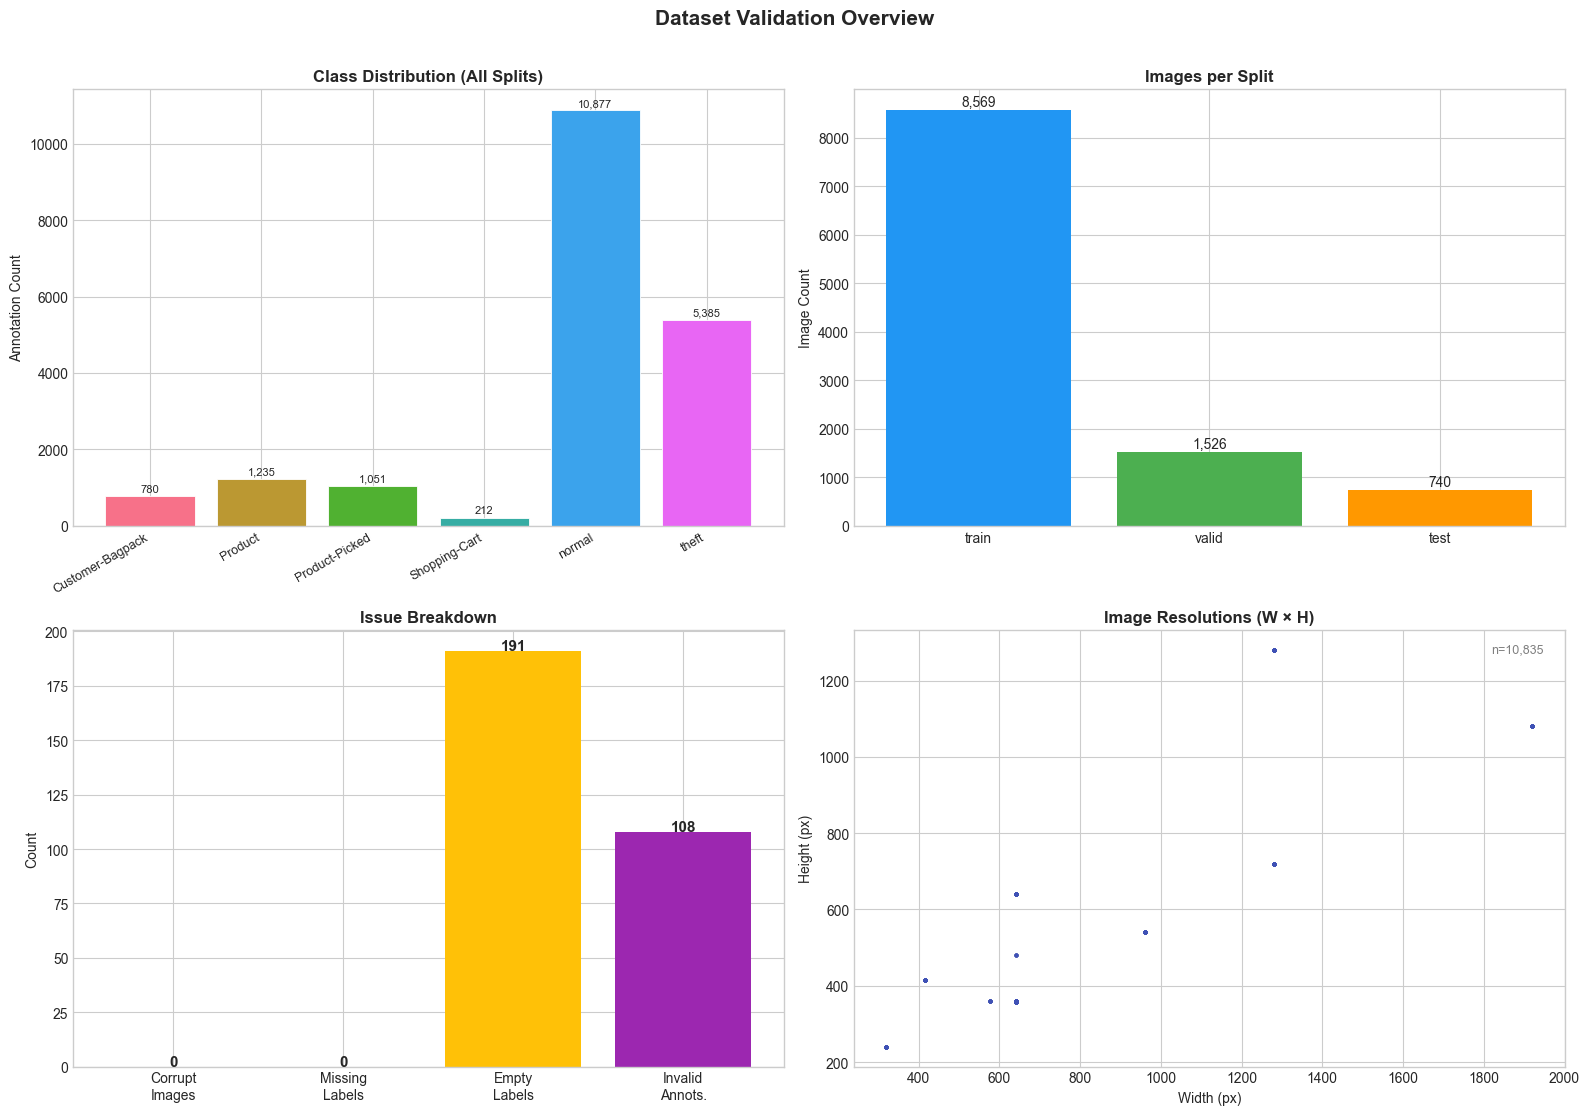

Chart saved → logs\01_validation_overview.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Dataset Validation Overview', fontsize=15, fontweight='bold', y=1.01)

PALETTE = sns.color_palette('husl', NUM_CLASSES)

# ── 1. Class distribution ───────────────────────────────────
ax = axes[0, 0]
counts_list = [global_class_cnt.get(i, 0) for i in range(NUM_CLASSES)]
bars = ax.bar(range(NUM_CLASSES), counts_list, color=PALETTE, edgecolor='white', linewidth=0.6)
ax.set_title('Class Distribution (All Splits)', fontweight='bold')
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Annotation Count')
for b, c in zip(bars, counts_list):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + total_anns * 0.003,
            f'{c:,}', ha='center', va='bottom', fontsize=8)

# ── 2. Images per split ─────────────────────────────────────
ax = axes[0, 1]
sp_names  = list(split_stats.keys())
sp_counts = [split_stats[s]['total'] for s in sp_names]
split_colors = ['#2196F3', '#4CAF50', '#FF9800']
sp_bars = ax.bar(sp_names, sp_counts, color=split_colors[:len(sp_names)])
ax.set_title('Images per Split', fontweight='bold')
ax.set_ylabel('Image Count')
for b, v in zip(sp_bars, sp_counts):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + max(sp_counts) * 0.01,
            f'{v:,}', ha='center', fontsize=10)

# ── 3. Issue counts ─────────────────────────────────────────
ax = axes[1, 0]
issue_labels = ['Corrupt\nImages', 'Missing\nLabels', 'Empty\nLabels', 'Invalid\nAnnots.']
issue_vals   = [total_corrupt, total_missing, total_empty, total_invalid]
issue_colors = ['#F44336', '#FF9800', '#FFC107', '#9C27B0']
ax.bar(issue_labels, issue_vals, color=issue_colors)
ax.set_title('Issue Breakdown', fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate(issue_vals):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=11, fontweight='bold')

# ── 4. Image resolution scatter ─────────────────────────────
ax = axes[1, 1]
all_shapes = []
for s in split_stats.values():
    all_shapes.extend(s['shapes'])
if all_shapes:
    hs = [sh[0] for sh in all_shapes]
    ws = [sh[1] for sh in all_shapes]
    ax.scatter(ws, hs, alpha=0.15, s=4, color='#3F51B5')
    ax.set_title('Image Resolutions (W × H)', fontweight='bold')
    ax.set_xlabel('Width (px)')
    ax.set_ylabel('Height (px)')
    ax.text(0.97, 0.97, f'n={len(all_shapes):,}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='gray')

plt.tight_layout()
out_path = LOG_DIR / '01_validation_overview.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved → {out_path}')

## Issue Examples (first 5 per category)

In [10]:
for issue_type, issues in all_issues.items():
    label = issue_type.replace('_', ' ').upper()
    if issues:
        print(f'\n{label}  ({len(issues):,} total):')
        for item in issues[:5]:
            print(f'  {item}')
        if len(issues) > 5:
            print(f'  ... and {len(issues) - 5} more (see log file)')
    else:
        print(f'\n{label}: None — OK')


CORRUPT IMAGES: None — OK

MISSING LABELS: None — OK

EMPTY LABELS  (191 total):
  {'split': 'train', 'file': '1_mp4-14_jpg.rf.23c9a2aa0e34d5fdcab3c5d03297a7ff.jpg'}
  {'split': 'train', 'file': '1_mp4-14_jpg.rf.4d79b268a9e128b4ef0d4047d9dd3f7a.jpg'}
  {'split': 'train', 'file': '1_mp4-14_jpg.rf.fa12964362256d7a1b7e0f42c0763cdc.jpg'}
  {'split': 'train', 'file': 'fshoplifting_2_11_534_jpg.rf.d2d00b3614c53e07ebac1c628cf7e375.jpg'}
  {'split': 'train', 'file': 'Robbery010_x264_0_29_png.rf.018fff96831dc0663629cca8fe01005e.jpg'}
  ... and 186 more (see log file)

INVALID ANNOTATIONS  (108 total):
  {'split': 'train', 'file': 'aahil_4_mp4-59_jpg.rf.55611ca3bc1a47a5c6505c127287f6e9.jpg', 'errors': ['L2: expected 5 fields, got 307']}
  {'split': 'train', 'file': 'Robbery013_x264_0_29_png.rf.0ebd7b264c6dfef772dafc7323c8e9b8.jpg', 'errors': ['L1: expected 5 fields, got 21', 'L2: expected 5 fields, got 17', 'L3: expected 5 fields, got 53', 'L4: expected 5 fields, got 31', 'L6: expected 5 fields

## Save Logs

In [11]:
# ── Full validation report ───────────────────────────────────
log_data = {
    'timestamp':  TIMESTAMP,
    'dataset':    str(BASE_DIR.resolve()),
    'classes':    CLASS_NAMES,
    'summary': {
        'total_images':       int(total_images),
        'corrupt':            int(total_corrupt),
        'missing_labels':     int(total_missing),
        'empty_labels':       int(total_empty),
        'invalid_annotations':int(total_invalid),
        'valid_pairs':        int(total_valid),
    },
    'split_stats': {
        sp: {
            k: (dict(v) if isinstance(v, Counter) else v)
            for k, v in stats.items()
            if k != 'shapes'   # skip large shape list
        }
        for sp, stats in split_stats.items()
    },
    'global_class_counts': {int(k): int(v) for k, v in global_class_cnt.items()},
    'issues': all_issues,
}

report_path = LOG_DIR / f'01_validation_report_{TIMESTAMP}.json'
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(log_data, f, indent=2, default=str)

# ── Valid-pairs list (used by NB02, NB03) ────────────────────
pairs_path = LOG_DIR / 'valid_files.json'
with open(pairs_path, 'w', encoding='utf-8') as f:
    json.dump(all_valid_pairs, f, indent=2)

print('Logs saved:')
print(f'  {report_path}')
print(f'  {pairs_path}')
print()
print('=' * 50)
print('NOTEBOOK 01 COMPLETE')
print('Next: run  02_dataset_cleaning.ipynb')
print('=' * 50)

Logs saved:
  logs\01_validation_report_20260408_213841.json
  logs\valid_files.json

NOTEBOOK 01 COMPLETE
Next: run  02_dataset_cleaning.ipynb
